# Notebook for comparing jet clustering from constituents and jet features from dataset

## Preliminary stuff

In [1]:
#Import custom classes and libraries
from src.Data.data_loading import ParquetDataModule
from src.Data.data_loading import ParquetFeatureDataset
from src.Data.data_loading import ParquetJetFeatureDataset

import yaml
import numpy as np
import fastjet
from tqdm import tqdm
import torch
import matplotlib.pyplot as plt


#Open config file
with open("Configs/config.yaml") as f:
    config = yaml.safe_load(f)

#Extract config info
dirs_train = config["data"]["train_path"]
dirs_val = config["data"]["val_path"]
dirs_test = config["data"]["test_path"]

features_cols = config["data"]["features"]
jet_features_cols = config["data"]["jet_features"]


#Initialization of itarable dataset (train dataset) containing the constituents' features (eta, phi, pT)
#In particular I am currently using the first 4 parquet files
dataset = ParquetFeatureDataset(
    parquet_dirs=dirs_train,
    features=features_cols,
    preprocessing=False
    #max_particles=256,
    #batch_size=32
)

#Initialization of itarable dataset (train dataset) containing the jets' features (pT, eta, phi, mass)
dataset_jet = ParquetJetFeatureDataset(
    parquet_dirs=dirs_train,
    features=jet_features_cols,
    #batch_size=32
)

## Jet features from dataset

In [2]:
#Definition of a function that build a numpy array which contains all the jets' masses in the dataset
#The function also performs a plot of the mass distribution 
def ds_jet_mass_distribution(jet_dataset, R=0.4, plot=True):
    
    #Initialization
    all_dataset_jet_masses = []

    feature_col = "L1T_JetPuppiAK4_Mass"

    if R == 0.8:
        feature_col = "L1T_JetPuppiAK8_Mass"

    #Extract jet masses
    for batch in jet_dataset:
        for event in batch[feature_col]:
            for j in event:
                all_dataset_jet_masses.append(j)

    #Convert to numpy array
    all_dataset_jet_masses = np.array(all_dataset_jet_masses)


    #Plot if statement
    if plot == True:

        # Plot histogram
        plt.figure(figsize=(8,6))
        n_bins = 100
        
        lab = "4"
        col = "gray"
        if R == 0.8:
            lab = "8"
            col = "orange"

    
        plt.hist(all_dataset_jet_masses, bins=n_bins, histtype='stepfilled', color=col, density=True, label=f'Jet_AK{lab}_Mass from the dataset')
        plt.title("Jet mass distribution")
        plt.xlabel("Jet Mass (GeV)")
        plt.ylabel("Density")
        plt.grid(True)
        plt.legend()

        plt.show()
 
    #Return the array
    return all_dataset_jet_masses

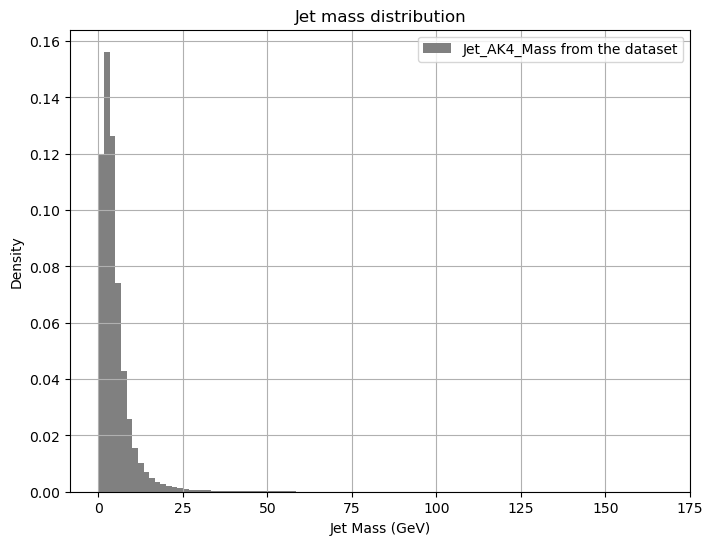

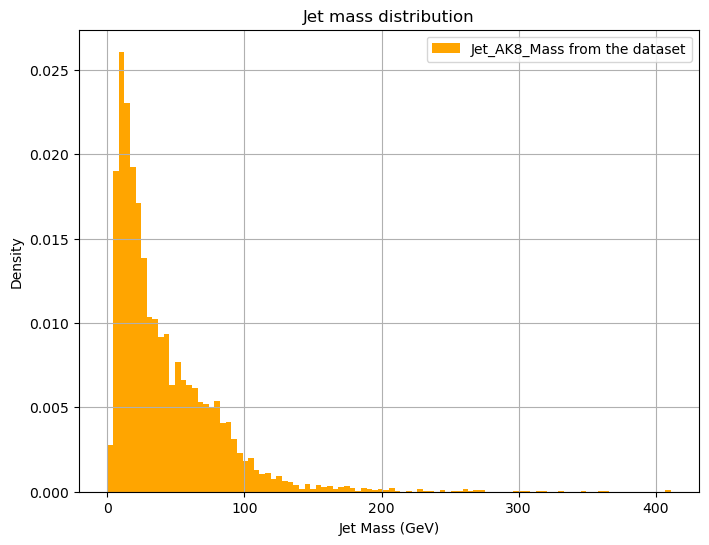

In [3]:
#R=0.4
all_dataset_jet_masses_AK4 = ds_jet_mass_distribution(dataset_jet, R=0.4, plot=True)

#R=0.8
all_dataset_jet_masses_AK8 = ds_jet_mass_distribution(dataset_jet, R=0.8, plot=True)

## Jet clustering from constituents

In [4]:
#Definition of a function that performs jet clustering from constituents
#It returns a list of lists containing the jet info (pT, eta, phi, mass) of each jet for each event
def cluster_jets(batch_tensor, mask, R=0.4, pt_min=20.0):
    
    jets_per_event = []

    for i in range(batch_tensor.shape[0]):

        #Select non-padded particles
        valid = batch_tensor[i][mask[i]]
        if valid.shape[0] == 0:
            jets_per_event.append([])
            continue

        # Build PseudoJet
        particles = []
        for eta, phi, pt in valid:
            #Compute 4‑vector components from (pt, eta, phi), mass=0
            px = pt * torch.cos(phi)
            py = pt * torch.sin(phi)
            pz = pt * torch.sinh(eta)
            E  = pt * torch.cosh(eta)
            particles.append(fastjet.PseudoJet(px.item(), py.item(), pz.item(), E.item()))

        #Set anti‑kt algo
        jet_def = fastjet.JetDefinition(fastjet.antikt_algorithm, R)

        #Clustering
        cluster_seq = fastjet.ClusterSequence(particles, jet_def)

        #Select jets with p_T > p_T_min
        inclusive = cluster_seq.inclusive_jets(pt_min)

        #Extract jets info
        jets_info = [(jet.perp(), jet.rapidity(), jet.phi(), jet.m()) for jet in inclusive]
        jets_per_event.append(jets_info)

    return jets_per_event

In [5]:
#Lists initialization
jets_AK4 = []
jets_AK8 = []

#Perform clustering 
for batch_tensor, mask in tqdm(dataset, desc="Wait just a moment, I am clustering jets", total=1084):
    
    #R=0.4
    batch_jet_AK4 = cluster_jets(batch_tensor, mask, R=0.4, pt_min=20.0)
    
    #R=0.8
    batch_jet_AK8 = cluster_jets(batch_tensor, mask, R=0.8, pt_min=20.0)
    
    jets_AK4.append(batch_jet_AK4)
    jets_AK8.append(batch_jet_AK8)

Wait just a moment, I am clustering jets:   0%|          | 1/1084 [00:01<19:16,  1.07s/it]

#--------------------------------------------------------------------------
#                         FastJet release 3.5.1
#                 M. Cacciari, G.P. Salam and G. Soyez                  
#     A software package for jet finding and analysis at colliders      
#                           https://fastjet.fr                           
#	                                                                      
# Please cite EPJC72(2012)1896 [arXiv:1111.6097] if you use this package
# for scientific work and optionally PLB641(2006)57 [hep-ph/0512210].   
#                                                                       
# FastJet is provided without warranty under the GNU GPL v2 or higher.  
# It uses T. Chan's closest pair algorithm, S. Fortune's Voronoi code,
# CGAL and 3rd party plugin jet algorithms. See COPYING file for details.
#--------------------------------------------------------------------------


Wait just a moment, I am clustering jets: 100%|██████████| 1084/1084 [01:16<00:00, 14.26it/s]


In [6]:
#Definition of a function that build a numpy array which contains all the clustered jets' masses 
#The function also performs a plot of the mass distribution 
def jet_mass_distribution(jet, R=0.4, plot=True):
    
    #Initialization
    all_jet_masses = []

    #Extract jet masses
    for batch in jet:
        for event in batch:
            for j in event:
                jet_mass = j[3]
                all_jet_masses.append(jet_mass)

    #Convert to numpy array
    all_jet_masses = np.array(all_jet_masses)

    
    #Plot if statement
    if plot == True:

        # Plot histogram
        plt.figure(figsize=(8,6))
        n_bins = 100

        lab = "4"
        col = "blue"
        if R == 0.8:
            lab = "8"
            col = "red"
    
        plt.hist(all_jet_masses, bins=n_bins, histtype='stepfilled', color=col, density=True, label=f'Jet_AK{lab}_Mass with custom clustering')
        plt.title("Jet mass distribution")
        plt.xlabel("Jet Mass (GeV)")
        plt.ylabel("Density")
        plt.grid(True)
        plt.legend()

        plt.show()


    return all_jet_masses

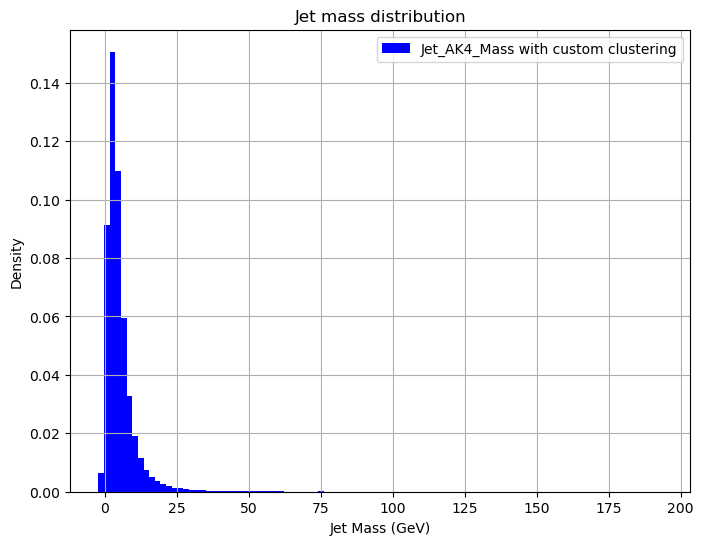

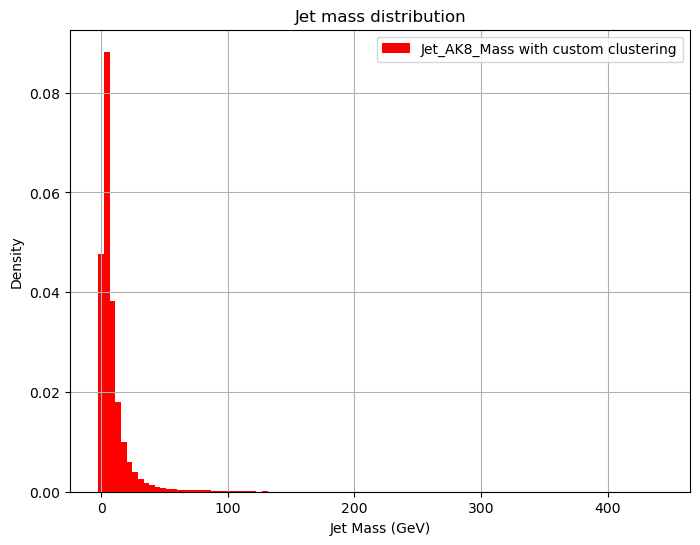

In [7]:
#R=0.4
all_jet_masses_AK4 = jet_mass_distribution(jets_AK4, R=0.4)

#R=0.8
all_jet_masses_AK8 = jet_mass_distribution(jets_AK8, R=0.8)

## Jet mass comparison

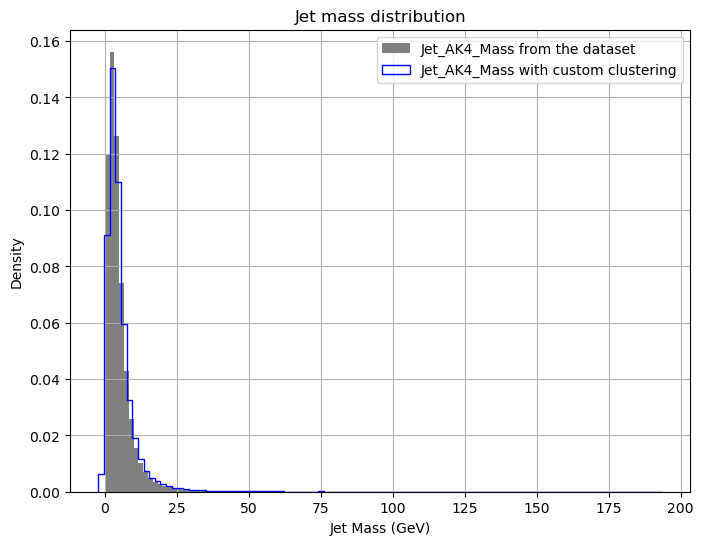

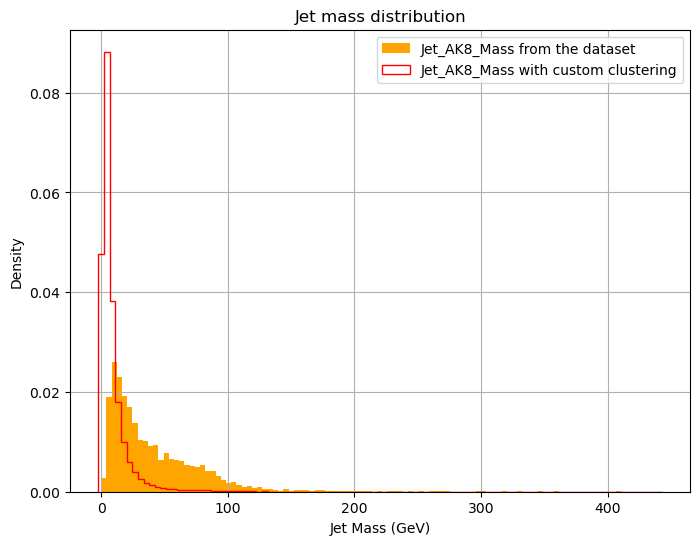

In [9]:
#AK4
plt.figure(figsize=(8,6))
n_bins = 100
       
plt.hist(all_dataset_jet_masses_AK4, bins=n_bins, histtype='stepfilled', color='gray', density=True, label='Jet_AK4_Mass from the dataset')
plt.hist(all_jet_masses_AK4, bins=n_bins, histtype='step', color='blue', density=True, label='Jet_AK4_Mass with custom clustering')
plt.title("Jet mass distribution")
plt.xlabel("Jet Mass (GeV)")
plt.ylabel("Density")
plt.grid(True)
plt.legend()

plt.show()

#AK8
plt.figure(figsize=(8,6))
n_bins = 100
       
plt.hist(all_dataset_jet_masses_AK8, bins=n_bins, histtype='stepfilled', color='orange', density=True, label='Jet_AK8_Mass from the dataset')
plt.hist(all_jet_masses_AK8, bins=n_bins, histtype='step', color='red', density=True, label='Jet_AK8_Mass with custom clustering')
plt.title("Jet mass distribution")
plt.xlabel("Jet Mass (GeV)")
plt.ylabel("Density")
plt.grid(True)
plt.legend()

plt.show()